In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
from google.colab import drive
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Lectura de la data

In [ ]:
# Define la ruta a los archivos
file_path = '/content/drive/MyDrive/Biomecatronica/TA/'

# Crea los dataframes
df_test_original = pd.read_csv(os.path.join(file_path, 'test.csv'))
df_train_original = pd.read_csv(os.path.join(file_path, 'train.csv'))
df_val_original = pd.read_csv(os.path.join(file_path, 'val.csv'))

# Puedes imprimir la información de los dataframes para verificar que se hayan cargado correctamente
print("Shape of df_test:", df_test_original.shape)
print("Shape of df_train:", df_train_original.shape)
print("Shape of df_val:", df_val_original.shape)

Shape of df_test: (41, 2)
Shape of df_train: (122, 2)
Shape of df_val: (41, 2)


#Procesamiento para extraer la data y pasarlo a un dataframe

In [ ]:
def extract_values_from_input(input_value):
    """
    Extrae los valores numéricos de una cadena de entrada en formato 'inputs'.

    Args:
        input_value (str): Cadena de texto que contiene los valores a procesar.

    Returns:
        list: Lista de números extraídos de la cadena de entrada.
    """
    # Filtrar los elementos que comienzan con 'array' o '[array'
    filtered_result = [x for x in input_value.split() if x.startswith('array') or x.startswith('[array')]

    # Extraer los números de cada elemento
    extracted_numbers = [
        float(
            x.replace('[array(', '')
             .replace('array(', '')
             .replace(')]', '')
             .replace(')', '')
             .replace('[', '')
             .replace(']', '')
        )
        for x in filtered_result
    ]

    return extracted_numbers

In [ ]:
def process_dataframe_inputs(df):
    """
    Procesa un DataFrame, separa los valores de 'inputs' en columnas individuales y conserva 'label'.

    Args:
        df (pd.DataFrame): DataFrame con una columna 'inputs' y una columna 'label'.

    Returns:
        pd.DataFrame: DataFrame con columnas para cada canal y la etiqueta 'label'.
    """
    # Inicializamos listas para los canales y las etiquetas
    channels_data = {f"channel_{i+1}": [] for i in range(6)}  # Para 6 canales
    labels = []

    for _, row in df.iterrows():
        # Extraer valores de la columna 'inputs'
        input_values = extract_values_from_input(row['inputs'])

        # Asignar valores a las listas de cada canal
        for i, value in enumerate(input_values):
            channels_data[f"channel_{i+1}"].append(value)

        # Guardar la etiqueta
        labels.append(row['label'])

    # Crear un DataFrame con los canales y la etiqueta
    processed_df = pd.DataFrame(channels_data)
    processed_df['label'] = labels

    return processed_df

In [ ]:
# Ejemplo de uso con df_train_original
test_df = process_dataframe_inputs(df_test_original)
train_df = process_dataframe_inputs(df_train_original)
val_df = process_dataframe_inputs(df_val_original)
# Puedes imprimir la información de los dataframes para verificar que se hayan cargado correctamente
print("Shape of df_test:", test_df.shape)
print("Shape of df_train:", train_df.shape)
print("Shape of df_val:", val_df.shape)

Shape of df_test: (41, 7)
Shape of df_train: (122, 7)
Shape of df_val: (41, 7)


In [ ]:
test_df

,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,label
0,-0.003949,-0.003949,-0.004100,0.000947,0.000786,0.001108,0
1,-0.003788,-0.002206,-0.002055,-0.009943,-0.007737,-0.007737,0
2,0.002055,0.001894,0.002206,-0.001894,-0.002055,-0.002841,2
3,0.000313,0.000313,0.000000,-0.022254,-0.015312,0.001581,1
4,0.000634,-0.000473,-0.000161,-0.003314,0.000000,0.000161,1
5,-0.000161,0.000634,-0.003153,0.013570,0.008684,0.012623,1
6,0.000000,-0.000634,-0.000473,0.000161,0.000313,0.000634,2
7,-0.128002,-0.146941,-0.238002,0.002680,0.011364,0.011676,2
8,0.018305,0.017992,0.011676,0.026354,0.020994,0.020672,2
9,0.002841,0.003002,0.002528,-0.002680,0.010104,0.010578,2


In [ ]:
train_df

,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,label
0,-0.000634,-0.000786,-0.000473,0.001733,0.002367,0.002206,2
1,0.005843,0.005208,0.001581,0.001733,0.000161,0.000161,1
2,-0.013258,-0.003475,-0.003002,0.001108,-0.001259,-0.001420,1
3,-0.004896,-0.005682,-0.004574,0.006468,0.004896,-0.008523,1
4,0.001420,0.001259,0.001581,0.006941,0.002528,0.003002,0
...,...,...,...,...,...,...,...
117,-0.003153,-0.003314,-0.003314,-0.001581,-0.001733,-0.005682,0
118,0.001733,0.002055,0.004896,0.000161,-0.000161,0.000000,1
119,0.000947,0.001108,0.000634,0.002367,0.002841,0.002680,2
120,-0.000473,0.000000,0.000000,0.000473,0.000161,0.000473,2


In [ ]:
val_df

,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,label
0,0.005521,0.004574,0.004574,0.001581,0.003475,0.003475,0
1,0.001581,0.000947,0.001108,-0.002841,-0.002841,-0.003949,0
2,0.002841,0.003153,0.002528,-0.077652,-0.007737,-0.030464,2
3,0.005682,0.005682,0.007102,-0.008049,-0.007888,-0.007102,2
4,0.019252,0.019574,0.025729,0.001420,0.001108,0.001581,2
5,-0.061553,-0.062973,-0.087434,-0.037405,-0.013258,-0.011837,2
6,-0.145047,-0.143939,-0.143627,-0.010729,-0.000161,0.000161,2
7,0.001259,-0.000786,-0.000634,-0.001420,-0.000786,-0.000786,2
8,0.000161,-0.000634,-0.000634,0.001259,0.000634,0.000947,2
9,0.000473,-0.001259,-0.001420,0.023201,0.023674,0.033305,2


#EDA

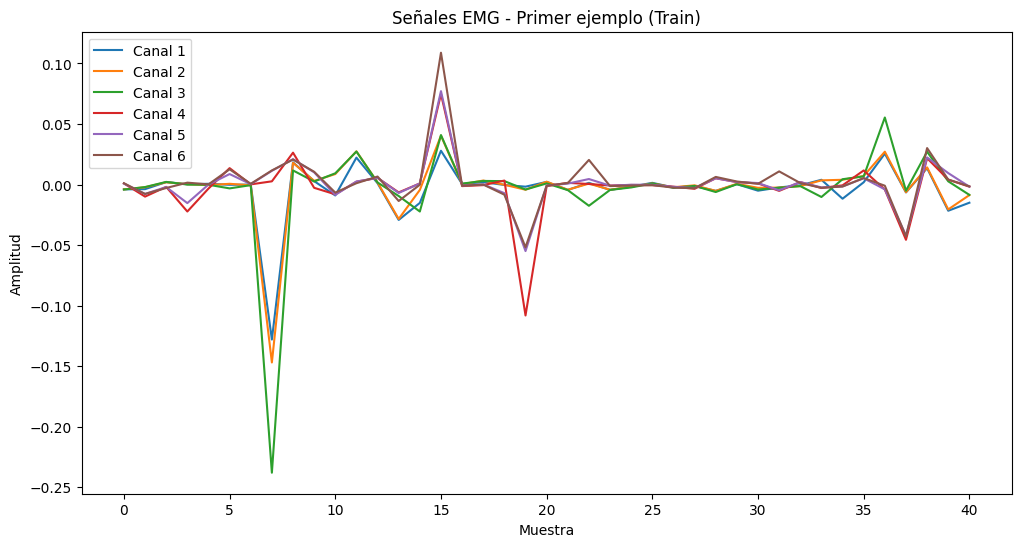

In [ ]:
# Visualizar las señales EMG del primer ejemplo
plt.figure(figsize=(12, 6))
for i, column in enumerate(test_df.columns[:-1], 1):
    plt.plot(test_df[column], label=f'Canal {i}')
plt.title('Señales EMG - Primer ejemplo (Train)')
plt.xlabel('Muestra')
plt.ylabel('Amplitud')
plt.legend()
plt.show()


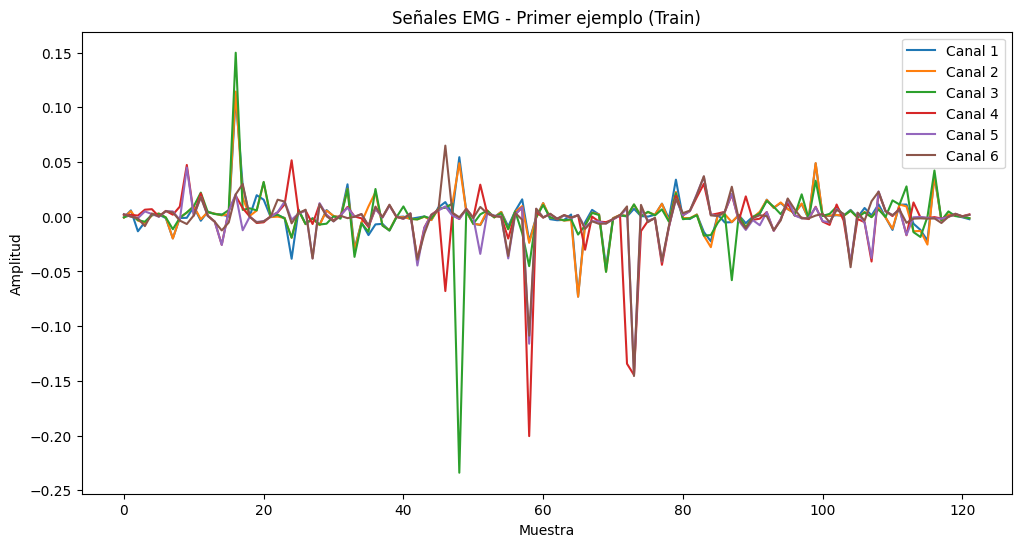

In [ ]:
# Visualizar las señales EMG del primer ejemplo
plt.figure(figsize=(12, 6))
for i, column in enumerate(train_df.columns[:-1], 1):
    plt.plot(train_df[column], label=f'Canal {i}')
plt.title('Señales EMG - Primer ejemplo (Train)')
plt.xlabel('Muestra')
plt.ylabel('Amplitud')
plt.legend()
plt.show()

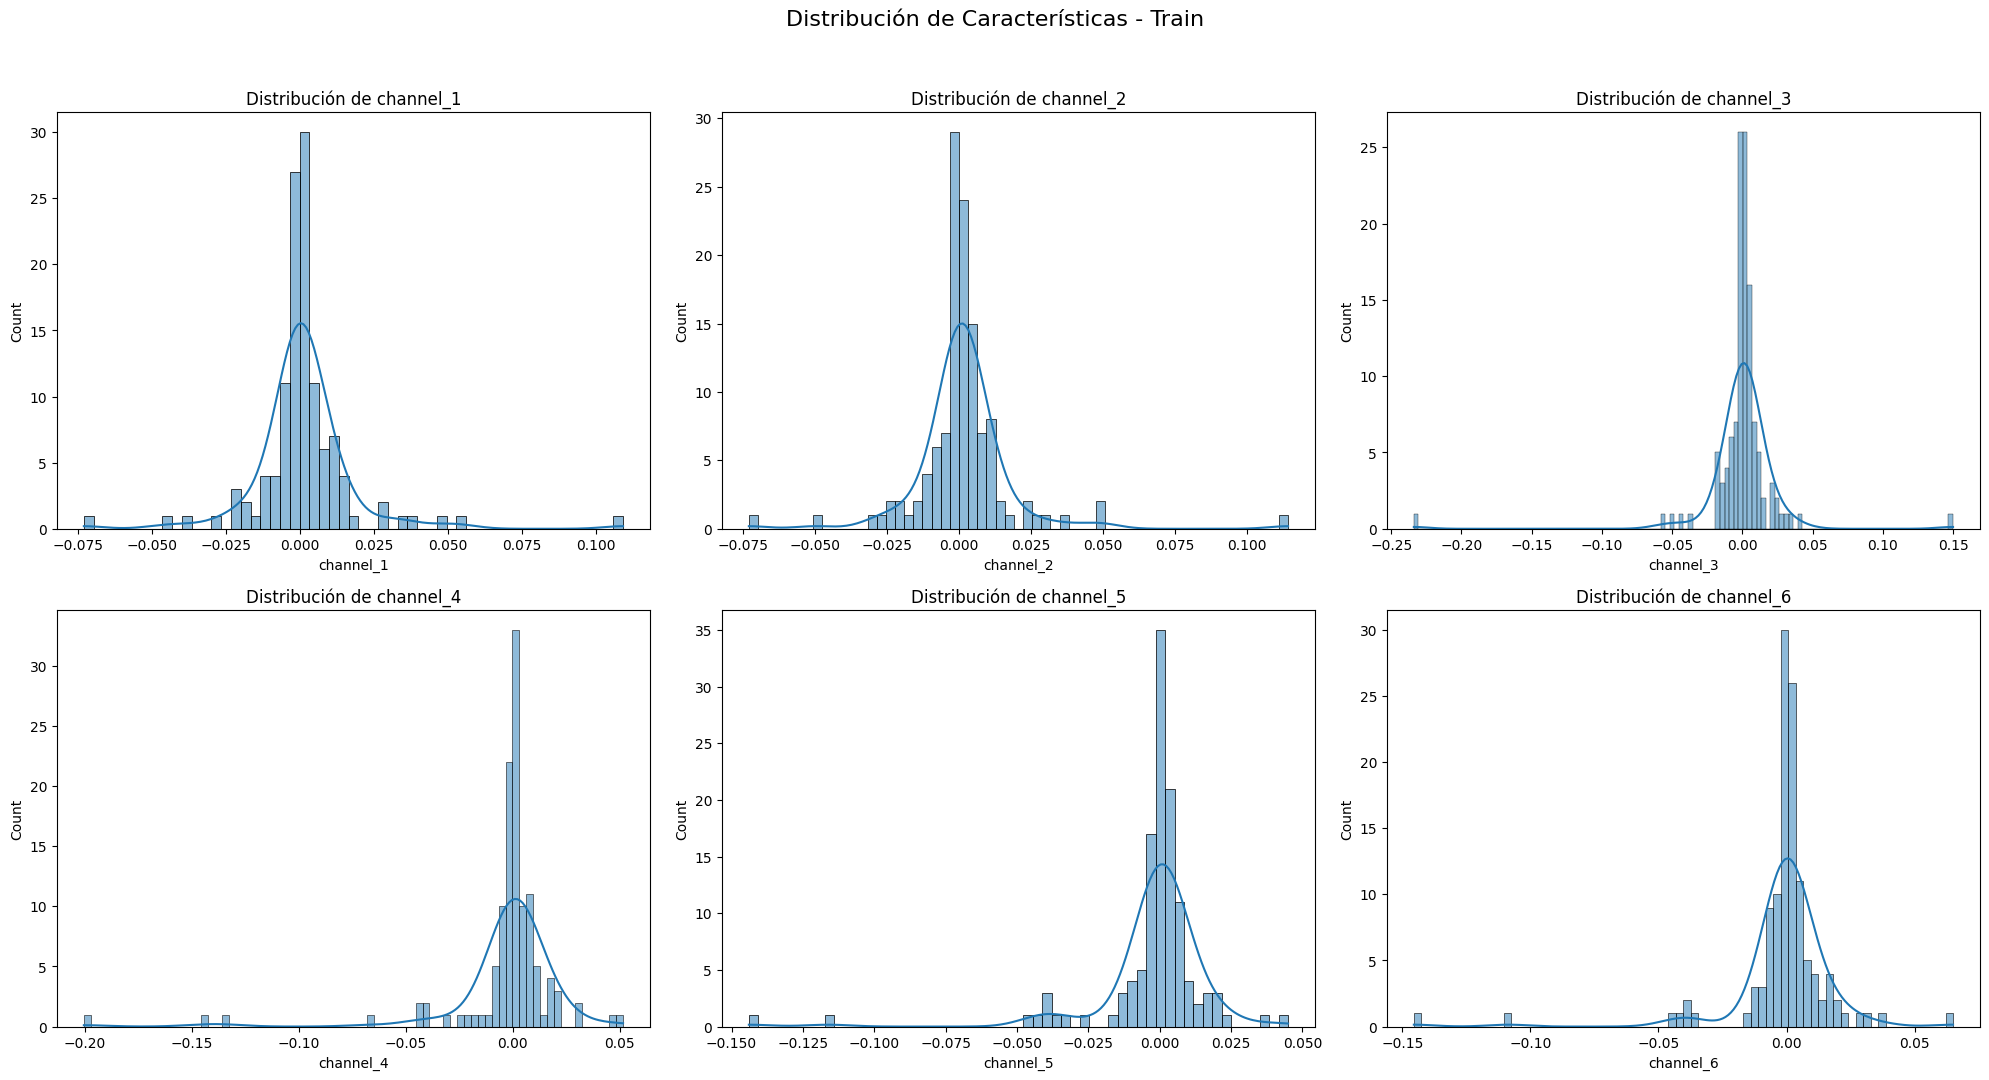

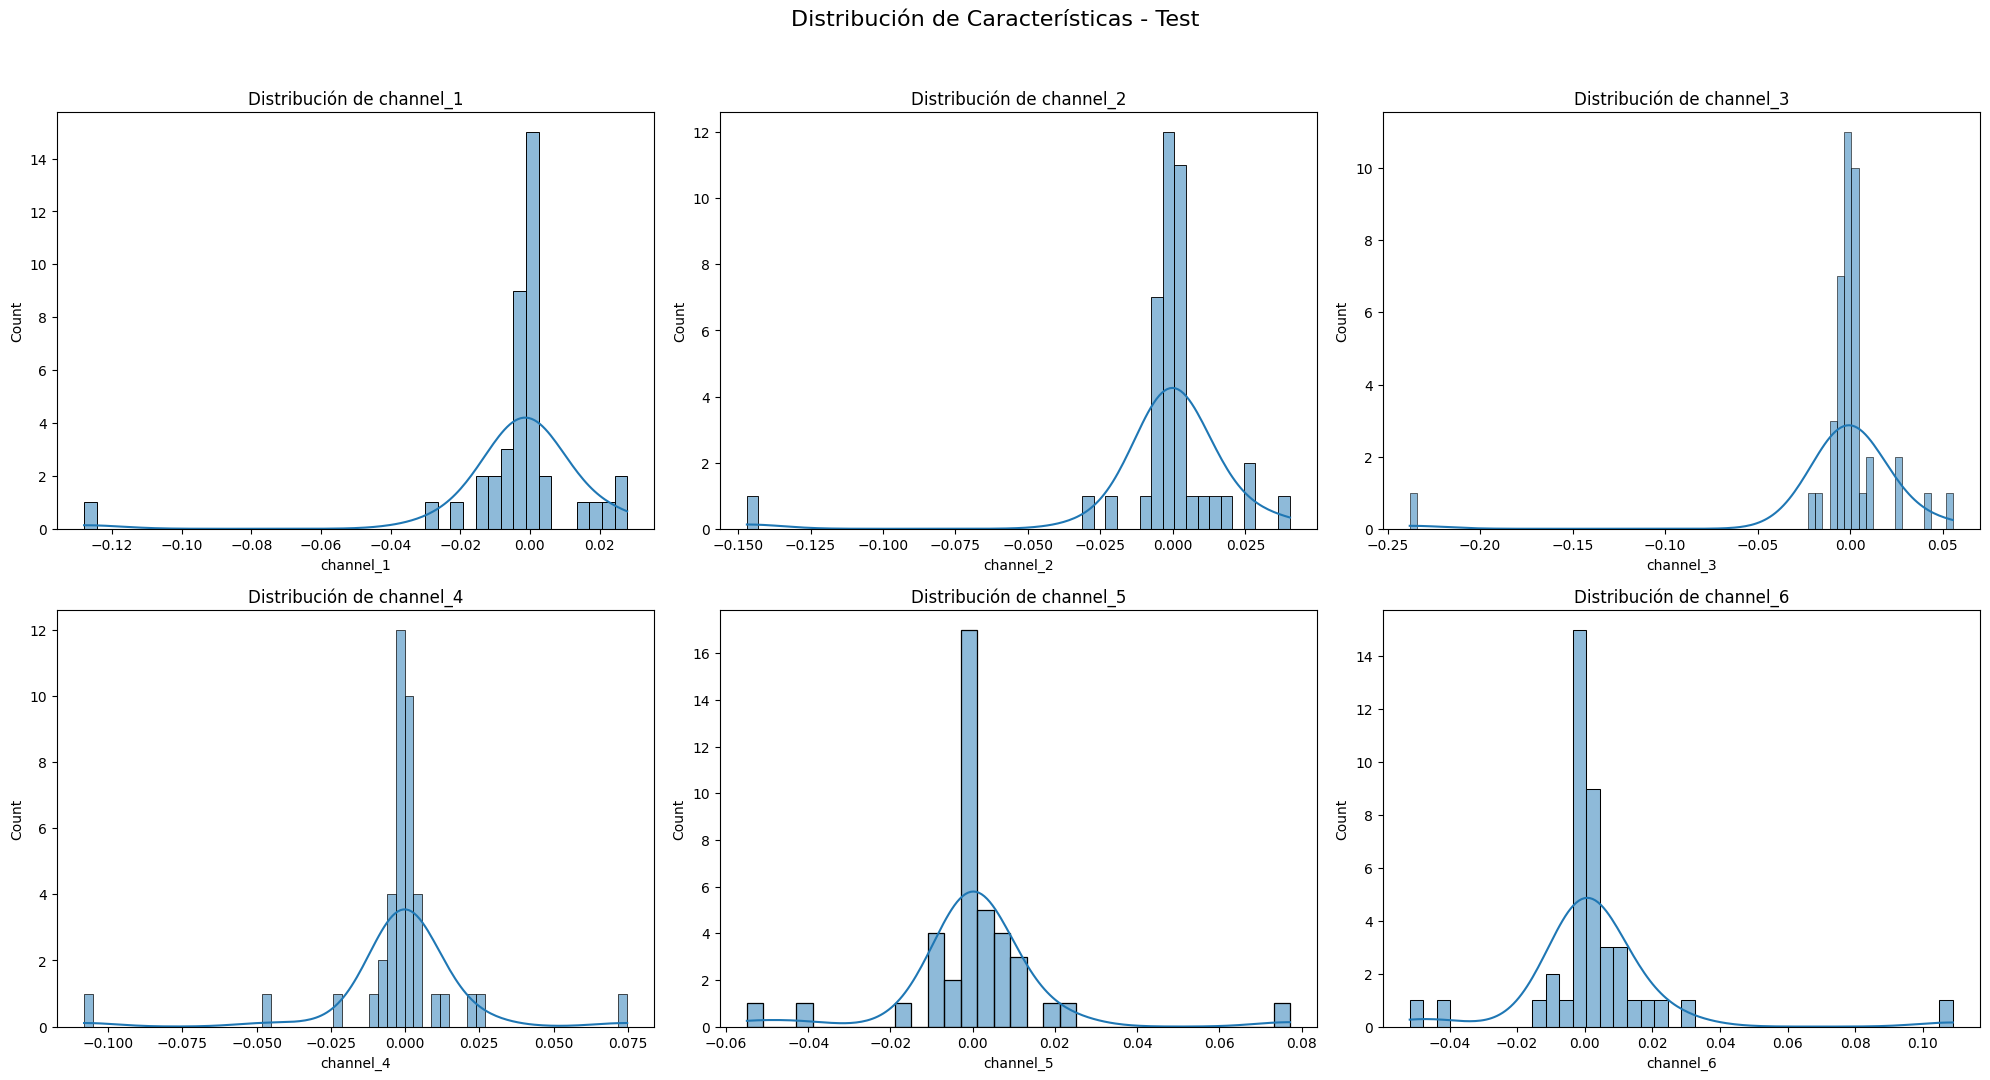

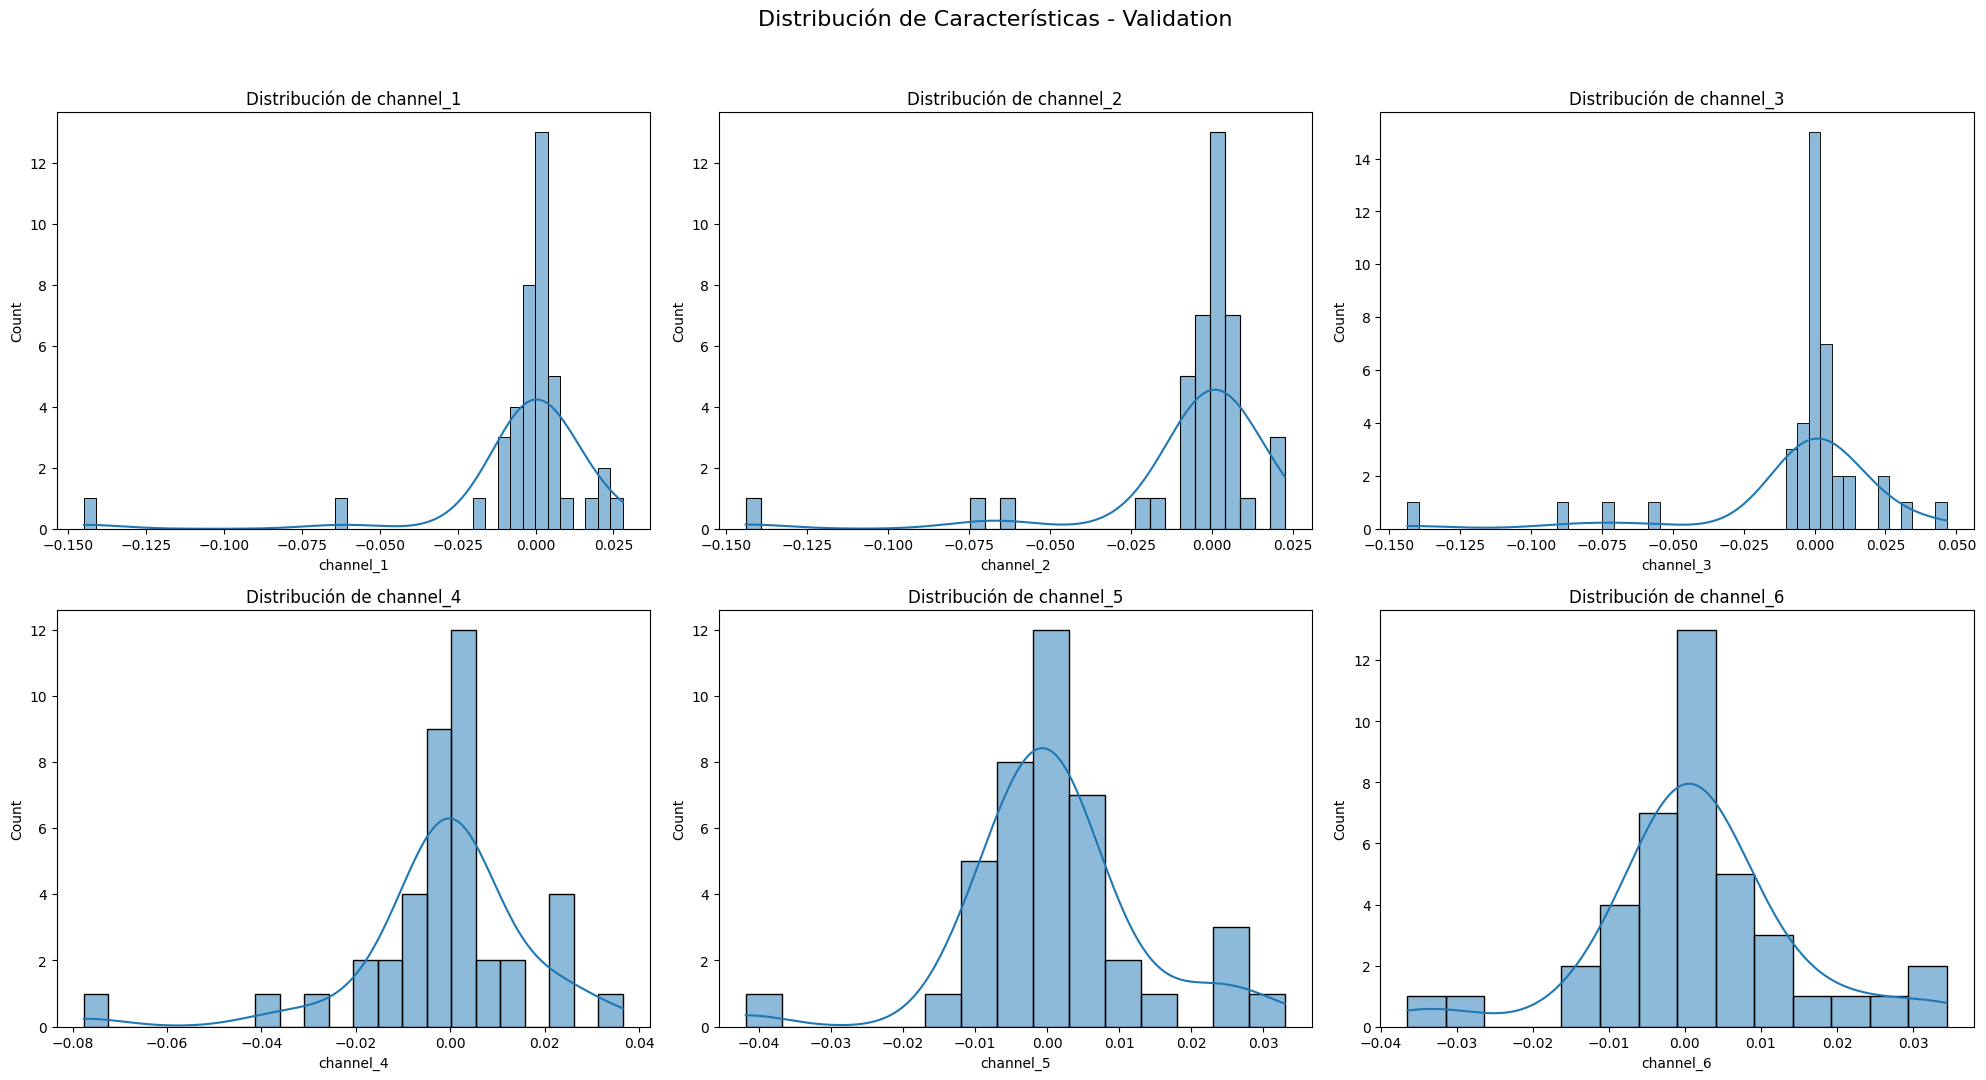

In [ ]:
def plot_feature_histograms(df, title):
    """
    Grafica la distribución de las características de un DataFrame utilizando histogramas y KDE.

    Args:
        df (pd.DataFrame): DataFrame procesado con características ('channel_1', ..., 'channel_n') y 'label'.
        title (str): Título del gráfico que indica el origen del conjunto de datos (Train, Test o Validation).
    """
    # Calcular la cantidad de características
    num_features = len(df.columns) - 1  # Excluir 'label'
    num_rows = (num_features // 3) + 1  # Ajusta el número de filas para 3 columnas

    # Crear la figura
    plt.figure(figsize=(20, 5 * num_rows))

    for i, column in enumerate(df.columns[:-1], 1):  # Itera sobre todas las columnas menos 'label'
        plt.subplot(num_rows, 3, i)
        sns.histplot(df[column], kde=True)  # Histogramas con curva KDE
        plt.title(f'Distribución de {column}')
        plt.xlabel(column)
        plt.ylabel('Count')

    # Título general del gráfico
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Uso de la función para los DataFrames
plot_feature_histograms(train_df, "Distribución de Características - Train")
plot_feature_histograms(test_df, "Distribución de Características - Test")
plot_feature_histograms(val_df, "Distribución de Características - Validation")


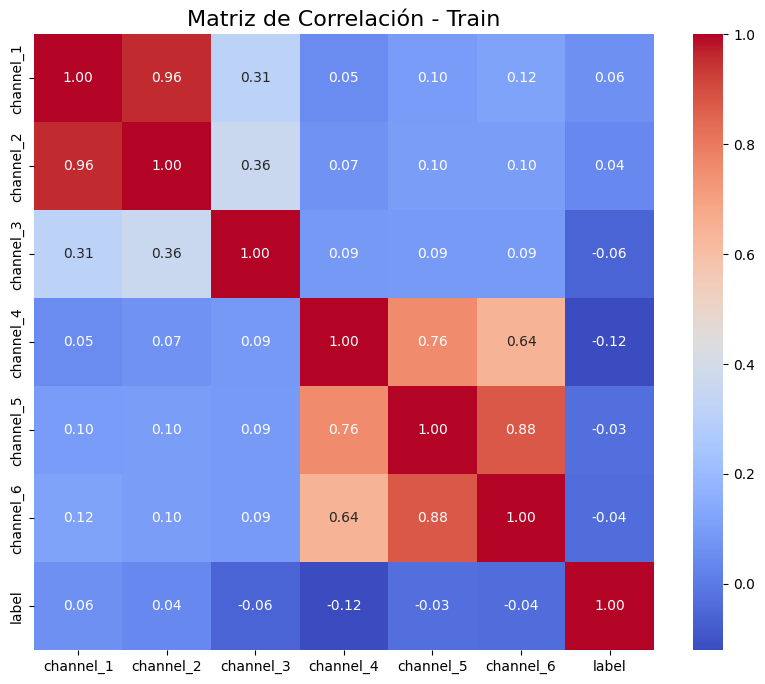

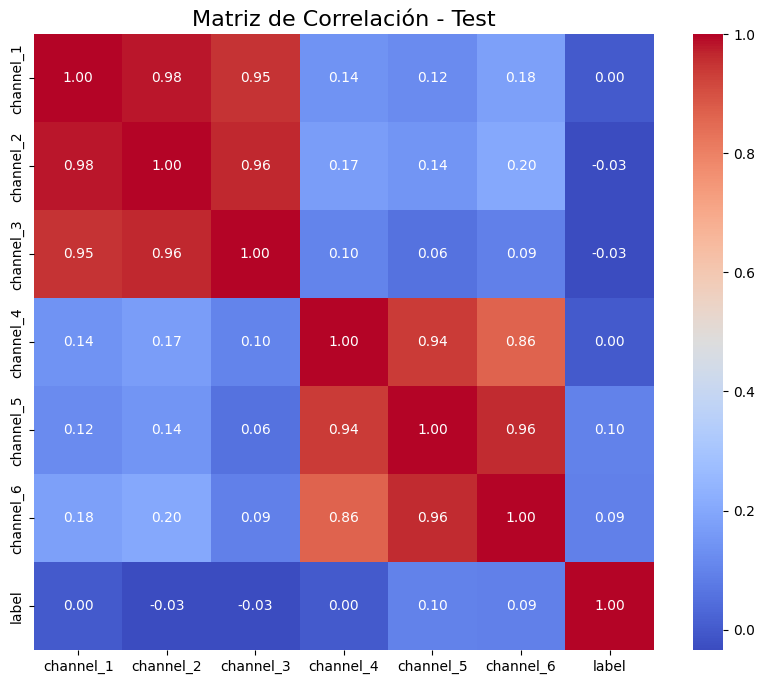

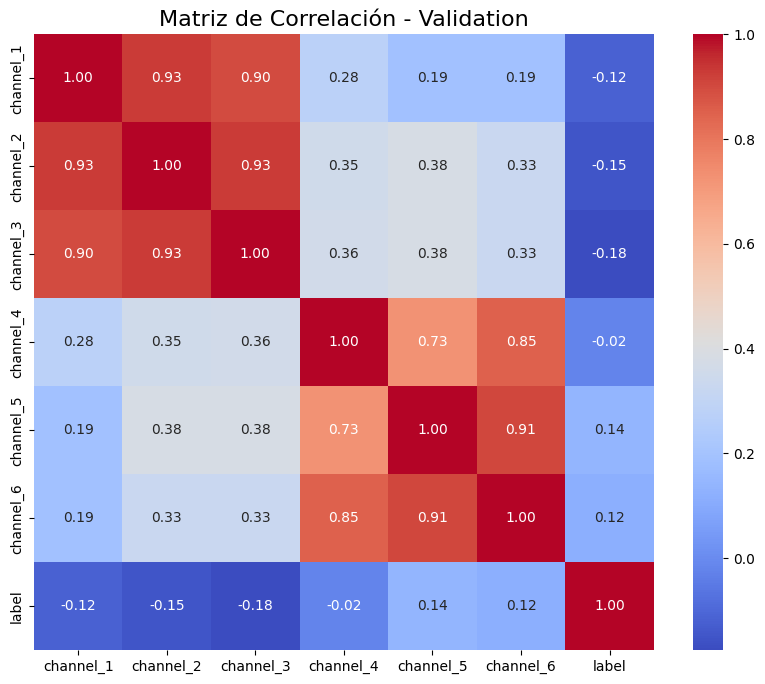

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_matrix(df, title):
    """
    Grafica la matriz de correlación entre las características y la etiqueta (label).

    Args:
        df (pd.DataFrame): DataFrame procesado con características ('channel_1', ..., 'channel_n') y 'label'.
        title (str): Título del gráfico que indica el origen del conjunto de datos (Train, Test o Validation).
    """
    # Calcular la matriz de correlación
    correlation_matrix = df.corr()

    # Graficar la matriz de correlación
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
    plt.title(title, fontsize=16)
    plt.show()

# Uso de la función para cada DataFrame
plot_correlation_matrix(train_df, "Matriz de Correlación - Train")
plot_correlation_matrix(test_df, "Matriz de Correlación - Test")
plot_correlation_matrix(val_df, "Matriz de Correlación - Validation")


#Verificación nulos y duplicados

In [ ]:
def check_missing_and_duplicates(df_dict):
    """
    Verifica y cuenta valores nulos y duplicados en múltiples DataFrames.

    Args:
        df_dict (dict): Un diccionario donde las claves son los nombres de los DataFrames
                        y los valores son los DataFrames correspondientes.

    Returns:
        None: Imprime los resultados de los conteos para cada DataFrame.
    """
    for name, df in df_dict.items():
        print(f"--- {name} ---")
        print(f"Valores nulos por columna:\n{df.isnull().sum()}")
        print(f"Total de valores nulos: {df.isnull().sum().sum()}")
        print(f"Total de filas duplicadas: {df.duplicated().sum()}")
        print("-" * 30)

# Diccionario con los DataFrames
dataframes = {
    "Train": train_df,
    "Test": test_df,
    "Validation": val_df
}

# Llamar a la función
check_missing_and_duplicates(dataframes)

--- Train ---
Valores nulos por columna:
channel_1    0
channel_2    0
channel_3    0
channel_4    0
channel_5    0
channel_6    0
label        0
dtype: int64
Total de valores nulos: 0
Total de filas duplicadas: 0
------------------------------
--- Test ---
Valores nulos por columna:
channel_1    0
channel_2    0
channel_3    0
channel_4    0
channel_5    0
channel_6    0
label        0
dtype: int64
Total de valores nulos: 0
Total de filas duplicadas: 0
------------------------------
--- Validation ---
Valores nulos por columna:
channel_1    0
channel_2    0
channel_3    0
channel_4    0
channel_5    0
channel_6    0
label        0
dtype: int64
Total de valores nulos: 0
Total de filas duplicadas: 0
------------------------------


#Extracción de características

In [ ]:
import pandas as pd
import numpy as np

def process_emg_data(df, window_size=6, step_size=3):
    """
    Procesa un DataFrame de señales EMG para extraer características usando ventanas deslizantes.

    Args:
        df (pd.DataFrame): DataFrame con señales en las primeras columnas y 'label' como última columna.
        window_size (int): Tamaño de la ventana en muestras.
        step_size (int): Tamaño del paso entre ventanas en muestras.

    Returns:
        pd.DataFrame: DataFrame con características extraídas y etiquetas asociadas.
    """
    features_list = []  # Lista para almacenar las características generadas

    for index, row in df.iterrows():
        label = row['label']  # Etiqueta de la fila actual
        signals = row[:-1].values  # Todas las columnas excepto 'label' (señales)

        # Crear ventanas deslizantes
        for start in range(0, len(signals) - window_size + 1, step_size):
            window = signals[start:start + window_size]

            # Calcular características para la ventana
            mav = np.mean(np.abs(window))  # Mean Absolute Value
            rms = np.sqrt(np.mean(np.square(window)))  # Root Mean Square
            wl = np.sum(np.abs(np.diff(window)))  # Waveform Length
            stddev = np.std(window)  # Desviación estándar

            # Guardar características
            features = {
                'MAV': mav,
                'RMS': rms,
                'WL': wl,
                'StdDev': stddev,
                'Label': label
            }
            features_list.append(features)

    # Convertir lista de características a un DataFrame
    features_df = pd.DataFrame(features_list)
    return features_df

In [ ]:
train_features = process_emg_data(train_df, window_size=6, step_size=3)
test_features = process_emg_data(test_df, window_size=6, step_size=3)
val_features = process_emg_data(val_df, window_size=6, step_size=3)

# Verifica los resultados
print(train_features.head())
print(test_features.head())
print(val_features.head())



        MAV       RMS        WL    StdDev  Label
0  0.001367  0.001566  0.003466  0.001383    2.0
1  0.002448  0.003337  0.005985  0.002268    1.0
2  0.003920  0.005798  0.016894  0.004583    1.0
3  0.005840  0.005995  0.027926  0.005633    1.0
4  0.002789  0.003408  0.010729  0.001959    0.0
        MAV       RMS        WL    StdDev  Label
0  0.002473  0.002908  0.005682  0.002475    0.0
1  0.005578  0.006351  0.011828  0.003038    0.0
2  0.002158  0.002182  0.005521  0.002179    2.0
3  0.006629  0.011048  0.046402  0.009345    1.0
4  0.000791  0.001394  0.008049  0.001291    1.0
        MAV       RMS        WL    StdDev  Label
0  0.003867  0.004062  0.005833  0.001243    0.0
1  0.002211  0.002462  0.005852  0.002250    0.0
2  0.020729  0.034259  0.173759  0.029218    2.0
3  0.006918  0.006982  0.017519  0.006940    2.0
4  0.011444  0.015392  0.031572  0.010293    2.0


In [ ]:
test_features

,MAV,RMS,WL,StdDev,Label
0,0.002473,0.002908,0.005682,0.002475,0.0
1,0.005578,0.006351,0.011828,0.003038,0.0
2,0.002158,0.002182,0.005521,0.002179,2.0
3,0.006629,0.011048,0.046402,0.009345,1.0
4,0.000791,0.001394,0.008049,0.001291,1.0
5,0.006471,0.008458,0.030133,0.006538,1.0
6,0.000369,0.000438,0.001903,0.000438,2.0
7,0.089777,0.125760,0.359678,0.096029,2.0
8,0.019332,0.019823,0.026989,0.004384,2.0
9,0.005289,0.006385,0.019100,0.004632,2.0


#Normalización

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

def normalize_dataframe(df):
    """
    Normaliza las características de un DataFrame usando StandardScaler.

    Args:
        df (pd.DataFrame): DataFrame con características y columna 'Label'.

    Returns:
        pd.DataFrame: DataFrame con características normalizadas y la columna 'Label'.
    """
    scaler = StandardScaler()

    # Seleccionar las columnas de características (excluyendo 'Label')
    feature_columns = [col for col in df.columns if col != 'Label']

    # Normalizar las características
    normalized_features = scaler.fit_transform(df[feature_columns])

    # Crear un nuevo DataFrame con las características normalizadas
    normalized_df = pd.DataFrame(normalized_features, columns=feature_columns)
    normalized_df['Label'] = df['Label'].values  # Añadir la columna 'Label'

    return normalized_df

In [ ]:
# Procesar cada conjunto por separado
train_norm = normalize_dataframe(train_features)
test_norm = normalize_dataframe(test_features)
val_norm = normalize_dataframe(val_features)

# Verifica los resultados
print(train_norm.head())
print(test_norm.head())
print(val_norm.head())

        MAV       RMS        WL    StdDev  Label
0 -0.640333 -0.610778 -0.514076 -0.579503    2.0
1 -0.562123 -0.517237 -0.475727 -0.519486    1.0
2 -0.455599 -0.387263 -0.309643 -0.362545    1.0
3 -0.316763 -0.376866 -0.141686 -0.291386    1.0
4 -0.537462 -0.513492 -0.403498 -0.540449    0.0
        MAV       RMS        WL    StdDev  Label
0 -0.466736 -0.454018 -0.457412 -0.394460    0.0
1 -0.283674 -0.300616 -0.354729 -0.358984    0.0
2 -0.485349 -0.486382 -0.460102 -0.413161    2.0
3 -0.221691 -0.091333  0.222920  0.039125    1.0
4 -0.565945 -0.521466 -0.417858 -0.469187    1.0
        MAV       RMS        WL    StdDev  Label
0 -0.497234 -0.520433 -0.685589 -0.625540    0.0
1 -0.614774 -0.607356 -0.685140 -0.541484    0.0
2  0.699908  1.120267  3.297915  1.709074    2.0
3 -0.280641 -0.361774 -0.408386 -0.150083    2.0
4  0.040718  0.095185 -0.075023  0.129752    2.0


In [ ]:
test_norm

,MAV,RMS,WL,StdDev,Label
0,-0.466736,-0.454018,-0.457412,-0.394460,0.0
1,-0.283674,-0.300616,-0.354729,-0.358984,0.0
2,-0.485349,-0.486382,-0.460102,-0.413161,2.0
3,-0.221691,-0.091333,0.222920,0.039125,1.0
4,-0.565945,-0.521466,-0.417858,-0.469187,1.0
5,-0.230998,-0.206727,-0.048896,-0.138039,1.0
6,-0.590794,-0.564056,-0.520541,-0.523027,2.0
7,4.681337,5.019569,5.457045,5.510008,2.0
8,0.527402,0.299627,-0.101425,-0.273984,2.0
9,-0.300705,-0.299090,-0.233219,-0.258372,2.0


#Entrenamiento

Separamos las variables independientes (Características) y dependiente (label)

In [ ]:
# Separar características y etiquetas para cada conjunto
X_train = train_norm.drop(columns=['Label'])
y_train = train_norm['Label']

X_test = test_norm.drop(columns=['Label'])
y_test = test_norm['Label']

X_val = val_norm.drop(columns=['Label'])
y_val = val_norm['Label']

Escogemos los 3 modelos Ramdon Forest, SVC y MLP

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Definir los modelos con balance de clases
models = {
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "Support Vector Machine": SVC(random_state=42, probability=True, class_weight="balanced"),
    "Multilayer Perceptron": MLPClassifier(random_state=42, max_iter=5000)
}


Entrenamiento del modelo

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# Crear Stratified K-Fold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Diccionario para guardar los resultados
results_train = {}

for model_name, model in models.items():
    print(f"Entrenando modelo: {model_name}")

    # Guardar métricas por fold
    accuracy_scores = []
    f1_scores = []
    precision_scores = []
    recall_scores = []

    for train_index, test_index in skf.split(X_train, y_train):
        # Dividir los datos en folds
        X_train_fold, X_test_fold = X_train.iloc[train_index], X_train.iloc[test_index]
        y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]

        # Entrenar el modelo
        model.fit(X_train_fold, y_train_fold)

        # Predecir en el fold de test
        y_pred = model.predict(X_test_fold)

        # Calcular métricas
        accuracy_scores.append(accuracy_score(y_test_fold, y_pred))
        f1_scores.append(f1_score(y_test_fold, y_pred, average='weighted', zero_division=0))
        precision_scores.append(precision_score(y_test_fold, y_pred, average='weighted', zero_division=0))
        recall_scores.append(recall_score(y_test_fold, y_pred, average='weighted', zero_division=0))

    # Guardar métricas promedio
    results_train[model_name] = {
        "Accuracy Mean": np.mean(accuracy_scores),
        "F1-Score Mean": np.mean(f1_scores),
        "Precision Mean": np.mean(precision_scores),
        "Recall Mean": np.mean(recall_scores)
    }

# Mostrar resultados de entrenamiento
print("Resultados del entrenamiento:")
results_train_df = pd.DataFrame(results_train).T
print(results_train_df)

Entrenando modelo: Random Forest
Entrenando modelo: Support Vector Machine
Entrenando modelo: Multilayer Perceptron
Resultados del entrenamiento:
                        Accuracy Mean  F1-Score Mean  Precision Mean  \
Random Forest                0.564667       0.548605        0.574754   
Support Vector Machine       0.311667       0.293296        0.515363   
Multilayer Perceptron        0.631000       0.594068        0.580901   

                        Recall Mean  
Random Forest              0.564667  
Support Vector Machine     0.311667  
Multilayer Perceptron      0.631000  


Evaluación con test_df

Evaluando modelo: Random Forest en el conjunto de test


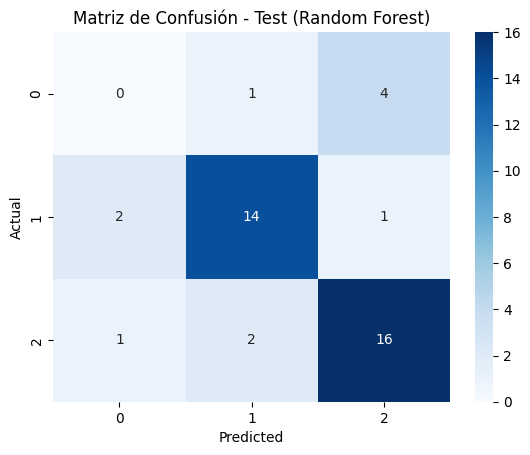

Evaluando modelo: Support Vector Machine en el conjunto de test


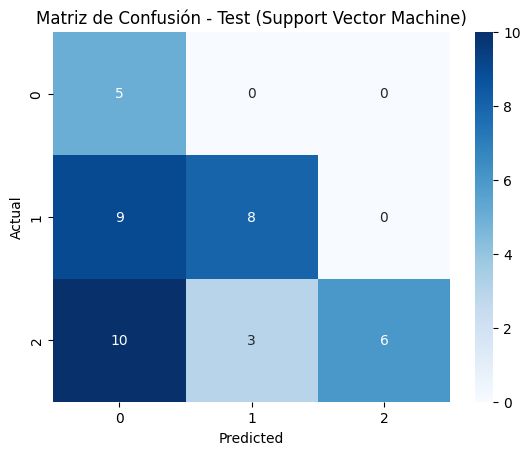

Evaluando modelo: Multilayer Perceptron en el conjunto de test


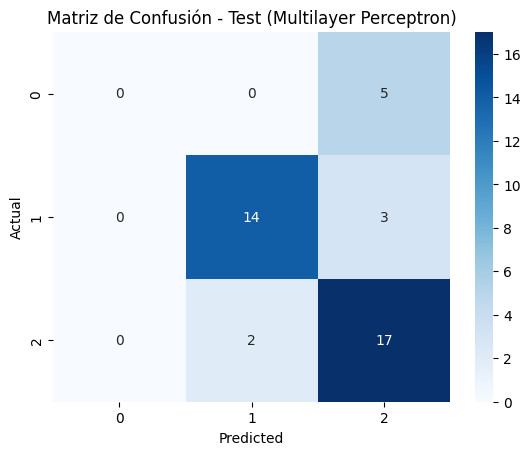

Resultados del conjunto de test:
                        Accuracy  F1-Score  Precision    Recall
Random Forest           0.731707  0.712195   0.694541  0.731707
Support Vector Machine  0.463415  0.501425   0.790373  0.463415
Multilayer Perceptron   0.756098  0.709904   0.677927  0.756098


In [ ]:
# Evaluar en el conjunto de test
results_test = {}

for model_name, model in models.items():
    print(f"Evaluando modelo: {model_name} en el conjunto de test")

    # Predecir
    y_test_pred = model.predict(X_test)

    # Calcular métricas
    accuracy = accuracy_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)

    # Guardar métricas
    results_test[model_name] = {
        "Accuracy": accuracy,
        "F1-Score": f1,
        "Precision": precision,
        "Recall": recall
    }

    # Mostrar matriz de confusión
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Matriz de Confusión - Test ({model_name})')
    plt.show()

# Mostrar resultados de test
print("Resultados del conjunto de test:")
results_test_df = pd.DataFrame(results_test).T
print(results_test_df)

Evaluación con val_df

Evaluando modelo: Random Forest en el conjunto de validación


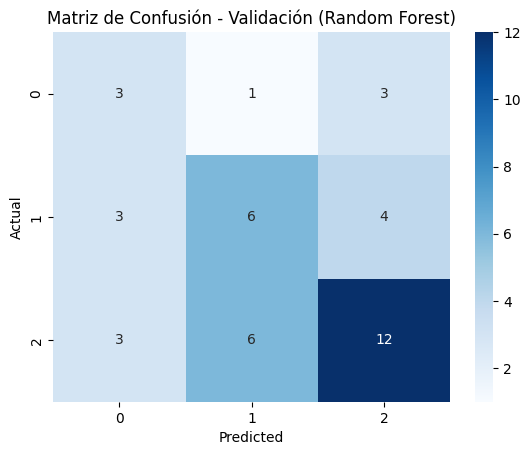

Evaluando modelo: Support Vector Machine en el conjunto de validación


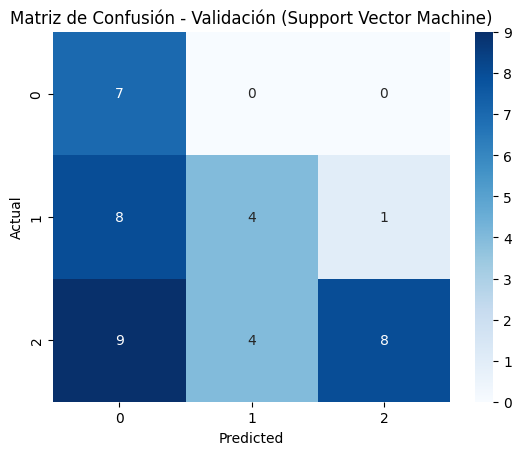

Evaluando modelo: Multilayer Perceptron en el conjunto de validación


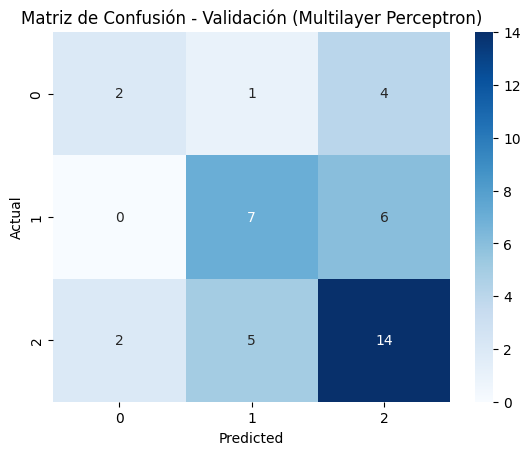

Resultados del conjunto de validación:
                        Accuracy  F1-Score  Precision    Recall
Random Forest           0.512195  0.517683   0.526744  0.512195
Support Vector Machine  0.463415  0.471065   0.663618  0.463415
Multilayer Perceptron   0.560976  0.551515   0.554878  0.560976


In [ ]:
# Evaluar en el conjunto de validación
results_val = {}

for model_name, model in models.items():
    print(f"Evaluando modelo: {model_name} en el conjunto de validación")

    # Predecir
    y_val_pred = model.predict(X_val)

    # Calcular métricas
    accuracy = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)
    precision = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
    recall = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)

    # Guardar métricas
    results_val[model_name] = {
        "Accuracy": accuracy,
        "F1-Score": f1,
        "Precision": precision,
        "Recall": recall
    }

    # Mostrar matriz de confusión
    cm = confusion_matrix(y_val, y_val_pred)
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Matriz de Confusión - Validación ({model_name})')
    plt.show()

# Mostrar resultados de validación
print("Resultados del conjunto de validación:")
results_val_df = pd.DataFrame(results_val).T
print(results_val_df)